# Defining train-validation splits for pretraining
* Similarity is defined by the L1 distance between one-hot vectors of blocks present in the graph
* We randomly sample centers from the dataset and keep the 99 closest neighbours based on the similarity measure as the validation set
* Continue to sample centers until we have a pre-defined number of validation samples

In [1]:
import pickle
import numpy as np
import faiss
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/frequency_split/QBioLiP-06-2024_data_frequency_vectors.pkl", "rb") as f:
    all_freq_vectors_dict = pickle.load(f)

In [13]:
# remove any PDBs that are involved in downstream finetuning 
exclude_pdbs = []
pdbbind_dir = "/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PDBBind/processed_PS_300/identity30/"
for split in ["train", "valid", "test"]:
    with open(f"{pdbbind_dir}/{split}.pkl", "rb") as f:
        data = pickle.load(f)
    pdbs = [item['id'] for item in data]
    print(f"PL30: {len(pdbs)}")
    exclude_pdbs.extend(pdbs)

pdbbind_dir = "/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PDBBind/processed_PS_300/identity60/"
for split in ["train", "valid", "test"]:
    with open(f"{pdbbind_dir}/{split}.pkl", "rb") as f:
        data = pickle.load(f)
    pdbs = [item['id'] for item in data]
    print(f"PL60: {len(pdbs)}")
    exclude_pdbs.extend(pdbs)

with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PPA/processed/PDBbind.pkl", "rb") as f:
    ppa_data = pickle.load(f)
ppa_pdbs = [item['id'] for item in ppa_data]
print(f"PPA train: {len(ppa_pdbs)}")
exclude_pdbs.extend(ppa_pdbs)

with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/datasets/PPA/processed/PPAB_V2.pkl", "rb") as f:
    ppa_data = pickle.load(f)
ppa_pdbs = [item['id'] for item in ppa_data]
print(f"PPA test: {len(ppa_pdbs)}")
exclude_pdbs.extend(ppa_pdbs)

plinder = pd.read_csv("/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/plinder/plinder_2024-06_v2_index_has_ba_remove_shared_binding_ids.csv")
plinder_pdbs = list(plinder['entry_pdb_id'].unique())
print(f"PLINDER: {len(plinder_pdbs)}")
exclude_pdbs.extend(plinder_pdbs)

merck_fep = ['5hnb', '4r1y', '3l9h', '8ck3', '5tbm', '6hvi', '5ehr', '4pv0', '4ui5'] # https://pubs.acs.org/doi/10.1021/ja512751q
exclude_pdbs.extend(merck_fep)

schrodinger_fep = ["4djw", "1h1q", "2gmx", "4hw3", "3fly", "2qbs", "2zff", "4gih"] # https://pubs.acs.org/doi/10.1021/ja512751q 
exclude_pdbs.extend(schrodinger_fep)

for idx, item in enumerate(exclude_pdbs):
    if len(item) != 4:
        print(item)
        exclude_pdbs[idx] = item[:4]

exclude_pdbs = set(exclude_pdbs)

PL30: 3485
PL30: 464
PL30: 487
PL60: 3542
PL60: 444
PL60: 450
PPA train: 2499
PPA test: 176
PLINDER: 11590
1a2k_C:AB
1acb_E:I
1ahw_AB:C
1ak4_A:D
1akj_AB:DE
1atn_A:D
1avx_A:B
1avz_B:C
1ay7_A:B
1b6c_A:B
1bj1_HL:VW
1brs_A:D
1buh_A:B
1bvk_DE:F
1bvn_P:T
1cbw_ABC:D
1de4_AB:CF
1dfj_E:I
1dqj_AB:C
1e4k_AB:C
1e6e_A:B
1e6j_HL:P
1e96_A:B
1eaw_A:B
1eer_A:BC
1efn_B:A
1emv_A:B
1ewy_A:C
1ezu_C:AB
1f34_A:B
1f6m_A:C
1fc2_C:D
1ffw_A:B
1fle_E:I
1fqj_A:B
1fsk_BC:A
1gcq_B:C
1gl1_A:I
1gla_G:F
1gpw_A:B
1grn_A:B
1gxd_A:C
1h1v_A:G
1h9d_A:B
1hcf_AB:X
1he8_B:A
1hia_AB:I
1i2m_A:B
1i4d_D:AB
1ib1_AB:E
1ibr_A:B
1ijk_A:BC
1j2j_A:B
1jiw_P:I
1jmo_A:HL
1jps_HL:T
1jtg_B:A
1jwh_CD:A
1k5d_AB:C
1kac_A:B
1kkl_ABC:H
1klu_AB:D
1ktz_A:B
1kxp_A:D
1kxq_H:A
1lfd_B:A
1m10_A:B
1mah_A:F
1mlc_AB:E
1mq8_A:B
1nb5_AP:I
1nca_HL:N
1nvu_Q:S
1nvu_R:S
1nw9_B:A
1oc0_A:B
1oph_A:B
1p2c_AB:C
1ppe_E:I
1pvh_A:B
1pxv_A:C
1qa9_A:B
1r0r_E:I
1r6q_A:C
1rlb_ABCD:E
1rv6_VW:X
1s1q_A:B
1t6b_X:Y
1us7_A:B
1vfb_AB:C
1wdw_BD:A
1wej_HL:F
1wq1_R:G
1xd3_A:B
1xqs_A:

In [17]:
start = 0
prev_dataset = None
datasets = {}
for idx, index_name in enumerate(all_freq_vectors_dict['indexes']):
    curr_dataset = "_".join(index_name.split("_")[:-1])
    if prev_dataset is None:
        prev_dataset = curr_dataset
    if curr_dataset != prev_dataset:
        dataset = all_freq_vectors_dict['freq_vectors'][start:idx, :]
        ids = [x[:4] for x in all_freq_vectors_dict['ids'][start:idx]]
        valid_ids = [i for i, id in enumerate(ids) if id not in exclude_pdbs]
        print(f"{prev_dataset} excluded pdbs:", len(ids) - len(valid_ids), len(ids))
        ids = all_freq_vectors_dict['ids'][start:idx]
        datasets[prev_dataset] = (dataset[valid_ids, :], [ids[i] for i in valid_ids])
        start = idx
        prev_dataset = curr_dataset
    if idx == len(all_freq_vectors_dict['indexes'])-1:
        dataset = all_freq_vectors_dict['freq_vectors'][start:, :]
        ids = [x[:4] for x in all_freq_vectors_dict['ids'][start:idx]]
        valid_ids = [i for i, id in enumerate(ids) if id not in exclude_pdbs]
        print(f"{curr_dataset} excluded pdbs:", len(ids) - len(valid_ids), len(ids))
        ids = all_freq_vectors_dict['ids'][start:idx]
        datasets[curr_dataset] = (dataset[valid_ids, :], [ids[i] for i in valid_ids])

PDNA_nonredund excluded pdbs: 27 2750
PRNA_nonredund excluded pdbs: 44 3511
PL_nonredund excluded pdbs: 8056 119017
PP_nonredund_fixed_ids excluded pdbs: 6315 124541
PRNA_nonredund excluded pdbs: 44 3511
Pion_nonredund excluded pdbs: 2547 74514
RNAL_nonredund excluded pdbs: 46 5185
Ppeptide_nonredund excluded pdbs: 444 8474


In [18]:
import random
def get_subset(dataset, num_subsample, num_neighbors=100, ensure_no_overlap=True):
    """
    Find a subset of the dataset such for each center index its num_neighbors are in the validation set.
    To ensure diversity of the subset we also ensure none of the center indexes share any neighbors with each other.
    Returns: center_indexes (list of indices), chosen_indexes (center indexes and their neighbours)
    """
    onehot_dataset = (dataset>0).astype(int)
    faiss_index = faiss.IndexFlat(onehot_dataset.shape[1], faiss.METRIC_L1)
    faiss_index.add(onehot_dataset)

    chosen_indexes = []
    remaining_indexes = set(np.arange(len(onehot_dataset)))
    random.seed(42)
    index = random.choice(list(remaining_indexes))
    num_centers = 0
    while len(chosen_indexes) < num_subsample:
        k = num_neighbors  # number of nearest neighbors
        D, I = faiss_index.search(onehot_dataset[index].reshape(1, -1), k)  # D is the distance, I is the index of neighbors
        I = I.flatten()
        assert index in I or D.mean() == 0
        if index not in I:
            I = np.concatenate([[index], I[:-1]])
        if len(chosen_indexes) == 0:
            chosen_indexes = I
            num_centers += 1
        else:
            new_chosen = I
            no_overlap = (len(set(chosen_indexes).intersection(set(new_chosen))) == 0)
            if no_overlap or not ensure_no_overlap:
                if not ensure_no_overlap:
                    chosen_indexes = np.concatenate([chosen_indexes, new_chosen])
                    chosen_indexes = np.unique(chosen_indexes)
                else: # no_overlap
                    chosen_indexes = np.concatenate([chosen_indexes, new_chosen])
                num_centers += 1
        print(num_centers, len(chosen_indexes), D.mean())
        remaining_indexes = remaining_indexes - set(chosen_indexes)
        index = random.choice(list(remaining_indexes))
    return chosen_indexes

In [19]:
datasets.keys()

dict_keys(['PDNA_nonredund', 'PRNA_nonredund', 'PL_nonredund', 'PP_nonredund_fixed_ids', 'Pion_nonredund', 'RNAL_nonredund', 'Ppeptide_nonredund'])

In [68]:
modality = 'Ppeptide_nonredund'
modality_dataset, modality_ids = datasets[modality]
print("Dataset size:", modality_dataset.shape)
print("Mean num blocks:", modality_dataset.sum(axis=1).mean())
print("Std num blocks:", modality_dataset.sum(axis=1).std())
print("Min num blocks:", modality_dataset.sum(axis=1).min())
print("Max num blocks:", modality_dataset.sum(axis=1).max())

Dataset size: (8030, 440)
Mean num blocks: 49.8359900373599
Std num blocks: 20.55558027175936
Min num blocks: 5.0
Max num blocks: 151.0


for large datasets we set num_neighbors = 100, for smaller datasets we set num_neighbors = 20

In [69]:
num_neighbors = {
    "PL_nonredund": 100,
    "PP_nonredund_fixed_ids": 100,
    "Pion_nonredund": 100,
    "Ppeptide_nonredund": 20,
    "PRNA_nonredund": 20,
    "PDNA_nonredund": 20,
    "RNAL_nonredund": 20,
}

In [70]:
validation_indexes = get_subset(modality_dataset, num_subsample=len(modality_dataset)*0.1, num_neighbors=num_neighbors[modality], ensure_no_overlap=True)
valid_ids = set([modality_ids[i] for i in validation_indexes])

1 20 1.75
2 40 0.0
3 60 4.7
4 80 2.25
4 80 1.05
5 100 0.0
6 120 1.25
7 140 1.35
8 160 2.5
9 180 2.1
10 200 2.65
11 220 0.9
12 240 1.65
13 260 0.0
14 280 2.0
15 300 0.3
15 300 0.45
16 320 2.75
17 340 1.15
17 340 1.75
17 340 0.95
18 360 0.0
19 380 0.0
20 400 1.8
20 400 2.25
20 400 0.7
20 400 0.45
20 400 2.55
21 420 1.0
21 420 0.8
22 440 1.6
22 440 0.0
22 440 0.0
23 460 0.0
23 460 1.65
24 480 1.6
25 500 2.55
25 500 0.75
25 500 0.35
25 500 0.0
25 500 1.15
25 500 0.0
25 500 1.4
26 520 0.3
26 520 0.0
26 520 0.0
27 540 1.7
28 560 2.9
29 580 1.75
30 600 0.75
31 620 2.95
32 640 1.65
33 660 3.55
34 680 0.0
34 680 0.0
34 680 0.7
35 700 0.3
35 700 2.3
36 720 3.55
36 720 0.2
37 740 1.8
37 740 1.75
38 760 0.0
38 760 0.95
38 760 0.45
39 780 0.0
39 780 2.2
39 780 2.8
39 780 0.3
39 780 1.85
39 780 0.0
39 780 4.0
39 780 0.0
40 800 1.05
41 820 0.95


In [71]:
remaining_indexes = sorted(set(np.arange(len(modality_ids))) - set(validation_indexes))
remaining_ids = [modality_ids[i] for i in remaining_indexes]
remaining_dataset = modality_dataset[remaining_indexes, :]
test_indexes = get_subset(remaining_dataset, num_subsample=len(modality_dataset)*0.1, num_neighbors=num_neighbors[modality], ensure_no_overlap=True)
test_ids = [remaining_ids[i] for i in test_indexes]

1 20 2.5
2 40 1.85
3 60 1.6
4 80 0.8
5 100 0.0
6 120 1.25
7 140 0.0
8 160 0.0
9 180 0.9
10 200 3.2
10 200 2.8
11 220 0.05
12 240 0.95
13 260 0.0
13 260 0.7
14 280 0.0
14 280 0.85
15 300 4.75
16 320 1.75
17 340 0.65
18 360 3.25
19 380 2.75
20 400 0.85
20 400 2.7
20 400 0.95
20 400 1.55
21 420 0.25
22 440 2.15
23 460 1.9
24 480 3.1
25 500 0.3
26 520 2.2
27 540 0.0
28 560 0.55
28 560 0.3
28 560 1.4
29 580 0.0
29 580 2.4
29 580 0.35
29 580 1.75


29 580 0.55
29 580 0.0
30 600 0.0
31 620 0.5
31 620 2.55
32 640 2.5
33 660 1.45
34 680 0.0
34 680 2.7
35 700 1.85
35 700 0.5
35 700 1.75
36 720 0.5
37 740 1.85
37 740 0.95
37 740 2.55
37 740 3.3
38 760 2.0
38 760 0.0
38 760 2.55
38 760 1.8
39 780 0.0
39 780 4.0
39 780 0.7
39 780 0.7
39 780 1.5
39 780 0.0
40 800 0.6
40 800 0.95
41 820 1.55


In [72]:
train_ids = set(remaining_ids) - set(test_ids)
len(train_ids), len(valid_ids), len(test_ids), len(train_ids) + len(valid_ids) + len(test_ids), len(modality_ids)

(6390, 820, 820, 8030, 8030)

In [73]:
with open(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/QBioLiP-06-2024-torsion/{modality}.pkl", "rb") as f:
    all_data = pickle.load(f)

In [74]:
train_data = [item for item in all_data if item['id'] in train_ids]
valid_data = [item for item in all_data if item['id'] in valid_ids]
test_data = [item for item in all_data if item['id'] in test_ids]
len(valid_data), len(test_data), len(train_data), len(all_data)-len(valid_data)-len(test_data)-len(train_data)

(820, 820, 6390, 445)

In [75]:
with open(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/{modality}_train.pkl", "wb") as f:
    pickle.dump(train_data, f)

with open(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/{modality}_valid.pkl", "wb") as f:
    pickle.dump(valid_data, f)

with open(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/{modality}_test.pkl", "wb") as f:
    pickle.dump(test_data, f)

# Combine all files

In [2]:
# combine files
MODALITIES = {
    "PP_nonredund_fixed_ids": "PP",
    "PL_nonredund": "PL", 
    "Pion_nonredund": "Pion", 
    "Ppeptide_nonredund": "Ppeptide", 
    "PRNA_nonredund": "PRNA", 
    "PDNA_nonredund": "PDNA", 
    "RNAL_nonredund": "RNAL"
}

data_dir = "/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/"

all_train = []
all_test = []
all_valid = []

for modality in MODALITIES: 
    with open(f"{data_dir}/{modality}_train.pkl", "rb") as f:
        train = pickle.load(f)
    for item in train:
        item['data']['modality'] = MODALITIES[modality]
    all_train.extend(train)
    with open(f"{data_dir}/{modality}_test.pkl", "rb") as f:
        test = pickle.load(f)
    for item in test:
        item['data']['modality'] = MODALITIES[modality]
    all_test.extend(test)
    with open(f"{data_dir}/{modality}_valid.pkl", "rb") as f:
        valid = pickle.load(f)
    for item in valid:
        item['data']['modality'] = MODALITIES[modality]
    all_valid.extend(valid)

print("All train:", len(all_train))
print("All valid:", len(all_valid))
print("All test:", len(all_test))

with open(f"{data_dir}/QBioLiP_test_with_modality.pkl", "wb") as f:
    pickle.dump(all_test, f)

with open(f"{data_dir}/QBioLiP_valid_with_modality.pkl", "wb") as f:
    pickle.dump(all_valid, f)

with open(f"{data_dir}/QBioLiP_train_with_modality.pkl", "wb") as f:
    pickle.dump(all_train, f)

All train: 256153
All valid: 32180
All test: 32180


In [91]:
train_indexes = list(range(len(all_train)))
random.seed(42)
random.shuffle(train_indexes)
subsample_train_indexes = train_indexes[:len(all_train)//10]
subsample_train = [all_train[i] for i in subsample_train_indexes]
with open(f"{data_dir}/QBioLiP_train_subsample10pc.pkl", "wb") as f:
    pickle.dump(subsample_train, f)

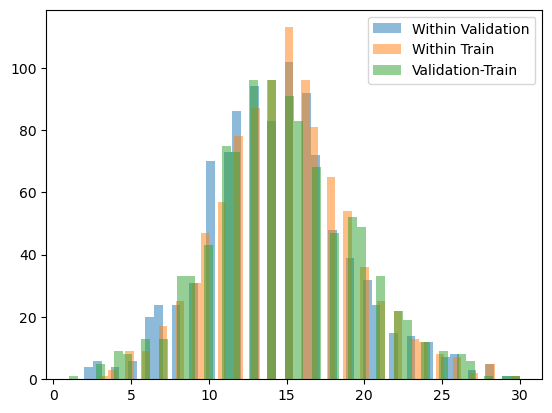

In [94]:
import random 

onehot_dataset = (modality_dataset>0).astype(int)

chosen_indexes = validation_indexes

distances_within_validation = []
distances_validation_train = []
distances_within_train = []
num_pairs = 1000
train_indexes = np.array(list(set(range(len(onehot_dataset))) - set(chosen_indexes)))

for i in range(num_pairs):
    idx1, idx2 = random.sample(chosen_indexes.tolist(), 2)
    dist = np.linalg.norm(onehot_dataset[idx1] - onehot_dataset[idx2], ord=1)
    distances_within_validation.append(dist)

indexes = random.sample(train_indexes.tolist(), 2*num_pairs)
for i in range(num_pairs):
    idx1, idx2 = indexes[i], indexes[i+num_pairs]
    dist = np.linalg.norm(onehot_dataset[idx1] - onehot_dataset[idx2], ord=1)
    distances_within_train.append(dist)

for i in range(num_pairs):
    idx1 = random.choice(chosen_indexes)
    idx2 = random.choice(train_indexes)
    dist = np.linalg.norm(onehot_dataset[idx1] - onehot_dataset[idx2], ord=1)
    distances_validation_train.append(dist)

plt.hist(distances_within_validation, bins=50, alpha=0.5, label='Within Validation')
plt.hist(distances_within_train, bins=50, alpha=0.5, label='Within Train')
plt.hist(distances_validation_train, bins=50, alpha=0.5, label='Validation-Train')
plt.legend(loc='upper right')
plt.show()


In [95]:
print(np.mean(distances_within_validation), np.std(distances_within_validation))
print(np.mean(distances_within_train), np.std(distances_within_train))
print(np.mean(distances_validation_train), np.std(distances_validation_train))

14.328 4.565130447205205
14.946 4.283816522681614
14.792 4.63408415978821
